# MCP Concepts 02: A LangGraph Agent as an MCP Client

## Problem card

- **What changes from notebook 01:** there, *we* manually called
  `list_tools`/`call_tool`. Here, a LangGraph **agent's LLM** decides which
  MCP tool to call and with what arguments, based on the user's question --
  the same tool-calling loop as `single_agent_architectures/01_react_single_agent.ipynb`,
  except the tools are loaded from real, separate MCP server processes
  instead of local `@tool`-decorated Python functions.
- **Why this matters:** once tools come from MCP, the *agent code itself
  doesn't change* whether a tool is a two-line local function or a call to a
  production service maintained by a different team -- `langchain-mcp-adapters`
  wraps each MCP tool as an ordinary LangChain tool, so `bind_tools`/`ToolNode`
  work exactly as they always do.
- **Servers used:** `calculator_server.py` (tools only) and
  `knowledge_ops_server.py` (tools/resources/prompts, only its tools are
  exposed to the agent here) -- both over **stdio**, both connected
  *simultaneously* to the same agent.
- **Success criteria:** one question that genuinely needs a tool from *each*
  server, answered correctly in one agent run.

## Architecture

```mermaid
flowchart TD
    U[User question] --> A["agent node\n(LLM + bind_tools)"]
    A -->|tool_calls present| T["tools node\n(ToolNode)"]
    A -->|no tool_calls| E[END]
    T -->|MCP call_tool, real subprocess round trip| A

    subgraph MCP Servers
        CS[calculator_server.py]
        KS[knowledge_ops_server.py]
    end
    T -.->|"stdio"| CS
    T -.->|"stdio"| KS

    style A fill:#a8dadc,stroke:#333
    style T fill:#f9c74f,stroke:#333
```

This is the *exact* same `agent -> tools -> agent` loop as a normal ReAct
agent -- the only difference is where `ToolNode`'s tools actually came from.

In [3]:
import os
import sys
import warnings
from typing import TypedDict, Annotated
from dotenv import load_dotenv, find_dotenv

warnings.filterwarnings("ignore")
load_dotenv(find_dotenv(usecwd=True))

sys.path.insert(0, os.getcwd())
import shared

from langchain_mcp_adapters.client import MultiServerMCPClient
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_openai import ChatOpenAI
from langchain_anthropic import ChatAnthropic

PROVIDER = os.getenv("PROVIDER", "openai").lower()
OPENAI_MODEL = os.getenv("OPENAI_MODEL", "gpt-4o-mini")
ANTHROPIC_MODEL = os.getenv("ANTHROPIC_MODEL", "claude-sonnet-5")

scorecard = shared.ScorecardCallback()


def get_llm(temperature: float = 0.0):
    if PROVIDER == "anthropic":
        return ChatAnthropic(model=ANTHROPIC_MODEL, temperature=temperature, callbacks=[scorecard])
    return ChatOpenAI(model=OPENAI_MODEL, temperature=temperature, callbacks=[scorecard])


CALCULATOR_SCRIPT = os.path.join(os.getcwd(), "servers", "calculator_server.py")
KNOWLEDGE_OPS_SCRIPT = os.path.join(os.getcwd(), "servers", "knowledge_ops_server.py")
print(f"Provider: {PROVIDER}")

Provider: openai


## Connecting to two MCP servers at once

`MultiServerMCPClient` takes a dict keyed by a name you choose for each
server, each entry describing how to reach it (`command`/`args` +
`transport: "stdio"` for a local subprocess server). `get_tools()` starts
each server, discovers its tools via `list_tools`, and returns them all as
one flat list of ordinary LangChain tools -- there's no persistent notion of
"which server" once they're in that list, which is exactly what notebook 03
digs into.

In [4]:
mcp_client = MultiServerMCPClient({
    "calculator": {"command": "python3", "args": [CALCULATOR_SCRIPT], "transport": "stdio"},
    "knowledge_ops": {"command": "python3", "args": [KNOWLEDGE_OPS_SCRIPT], "transport": "stdio"},
})

mcp_tools = await mcp_client.get_tools()
print(f"Loaded {len(mcp_tools)} tools from 2 MCP servers:")
for t in mcp_tools:
    print(f"  - {t.name}: {t.description}")

Loaded 8 tools from 2 MCP servers:
  - add: Add two numbers.
  - subtract: Subtract b from a.
  - multiply: Multiply two numbers.
  - divide: Divide a by b. Raises an error if b is zero.
  - percentage_of: Compute what percentage `part` is of `whole` (e.g. percentage_of(25, 200) -> 12.5).
  - search_runbooks: Search runbook titles for services matching a keyword (e.g. 'payment', 'login').
  - get_service_status: Get the current status, error rate, and last deploy time for a service.
  - check_status: Check status by id. (Deliberately vague -- see orders_server.py's module
docstring; used only in notebook 03's tool-naming-collision demo, not in
notebooks 01/02.)


## Building the agent graph

Same shape as `single_agent_architectures/01_react_single_agent.ipynb`:
`TypedDict` state with `add_messages`, an `agent` node that calls the LLM
with `bind_tools`, a `tools` node (`ToolNode`), and `tools_condition`
deciding whether to loop back for another tool call or end. The only
MCP-specific detail: MCP tools are async, so the agent node and the graph
invocation both use `ainvoke`.

In [5]:
class AgentState(TypedDict):
    messages: Annotated[list, add_messages]


llm_with_tools = get_llm(temperature=0.0).bind_tools(mcp_tools)


async def agent_node(state: AgentState) -> dict:
    response = await llm_with_tools.ainvoke(state["messages"])
    return {"messages": [response]}


builder = StateGraph(AgentState)
builder.add_node("agent", agent_node)
builder.add_node("tools", ToolNode(mcp_tools))
builder.add_edge(START, "agent")
builder.add_conditional_edges("agent", tools_condition, {"tools": "tools", "__end__": END})
builder.add_edge("tools", "agent")

mcp_agent = builder.compile()
print("Graph compiled.")

Graph compiled.


## The compiled graph

In [6]:
print(mcp_agent.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	agent(agent)
	tools(tools)
	__end__([<p>__end__</p>]):::last
	__start__ --> agent;
	agent -.-> __end__;
	agent -.-> tools;
	tools --> agent;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



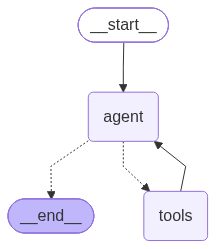

In [7]:
from IPython.display import Image, display

try:
    display(Image(mcp_agent.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Skipping PNG render (needs network access to mermaid.ink): {e}")

## Running a question that needs both servers

"What's the current error rate for the checkout service, and what would
double that error rate be?" requires `get_service_status` (knowledge_ops
server) *then* `multiply` (calculator server) -- two real MCP round trips
to two different subprocesses, chained by the agent's own reasoning, not
hand-coded by us.

In [8]:
scorecard.reset()
with shared.Timer() as t:
    result = await mcp_agent.ainvoke({
        "messages": [{"role": "user", "content":
            "What's the current error rate for the checkout service, "
            "and what would double that error rate be?"}]
    })

for m in result["messages"]:
    name = type(m).__name__
    tool_calls = getattr(m, "tool_calls", None)
    if tool_calls:
        for tc in tool_calls:
            print(f"[{name}] tool_call -> {tc['name']}({tc['args']})")
    elif getattr(m, "content", None):
        print(f"[{name}] {m.content}")

print(f"\nLLM calls: {scorecard.call_count}, wall clock: {t.elapsed_s:.2f}s")

[HumanMessage] What's the current error rate for the checkout service, and what would double that error rate be?
[AIMessage] tool_call -> get_service_status({'service': 'checkout'})
[ToolMessage] [{'type': 'text', 'text': '{"status":"degraded","error_rate_pct":18.4,"last_deploy_minutes_ago":40}', 'id': 'lc_ea7d37ea-e692-4ce1-b9a6-d889b7e3eab3'}]
[AIMessage] tool_call -> multiply({'a': 18.4, 'b': 2})
[ToolMessage] [{'type': 'text', 'text': '36.8', 'id': 'lc_d78242df-2fe8-4a07-92f2-6e9a7e2018b6'}]
[AIMessage] The current error rate for the checkout service is 18.4%. Doubling that error rate would result in 36.8%.

LLM calls: 3, wall clock: 8.31s


## Explain like I'm 12

Imagine you have a walkie-talkie (the agent) and two friends in different
rooms, each an expert at one thing -- one friend is great at math, the other
knows everything about how the school's systems are doing. You don't have
to know *how* to do the math or *how* to check the systems yourself -- you
just ask the right friend the right question over the walkie-talkie, wait
for their answer, and then maybe ask your other friend a follow-up question
using what the first friend told you. The walkie-talkie protocol (MCP) is
what lets you talk to *any* friend who has one, even ones you've never met
before, as long as they follow the same "here's what I can help with"
introduction rules from notebook 01.

## Checkpoint questions

1. **Q: Why does `agent_node` use `await llm_with_tools.ainvoke(...)`
   instead of the synchronous `.invoke(...)` used in
   `01_react_single_agent.ipynb`?**
   A: MCP tool calls are inherently async (they involve real I/O to a
   separate process over a pipe or socket), so `langchain-mcp-adapters`
   wraps every MCP tool as an async LangChain tool. `ToolNode` can only
   actually execute those tools when the graph itself is run with
   `.ainvoke()`, which requires every node in the chain, including the LLM
   call, to be awaitable too.

2. **Q: After `mcp_client.get_tools()`, is there anything in the returned
   list that still says which server a given tool came from?**
   A: No -- the list is just ordinary LangChain `BaseTool` objects; nothing
   about the return value marks `multiply` as having come from `calculator`
   vs. `get_service_status` from `knowledge_ops`. This is exactly the setup
   notebook 03 explores the consequences of.

3. **Q: If `knowledge_ops_server.py` crashed mid-conversation, what would
   happen to the `calculator` tools?**
   A: Nothing -- each server is its own subprocess with its own stdio pipe;
   one server's process dying doesn't affect the others. The agent would
   simply get a tool-call error the next time it tried to use a
   `knowledge_ops` tool, the same as any other tool failure.